<a href="https://colab.research.google.com/github/nithinpadmanabhuni-eng/Hypothesis-Testing-on-Interest-Rates/blob/main/Project_pneumonia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Importing the necessary Libraries

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras
import tensorflow as tf

from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D
from keras.layers import Flatten, Dropout, BatchNormalization

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from keras.callbacks import ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

import cv2
import os

###Pneumonia DataSet

In [22]:
labels = ['PNEUMONIA','NORMAL']
img_resize = 150

def get_data(dir):

    data = []

    for label in labels:

        path = os.path.join(dir, label)

        class_num = labels.index(label)

        for img in os.listdir(path):

            try:

                if img.endswith('jpeg'):

                    img_arr = cv2.imread(
                        os.path.join(path,img),
                        cv2.IMREAD_GRAYSCALE
                    )

                    resized_arr = cv2.resize(
                        img_arr,
                        (img_resize, img_resize)
                    )

                    data.append([resized_arr, class_num])

            except Exception as e:
                print(e)

    return np.array(data, dtype='object')


In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
train = get_data('/content/drive/MyDrive/Pneumonia_Project/chest_xray/train')
test = get_data('/content/drive/MyDrive/Pneumonia_Project/chest_xray/test')
val = get_data('/content/drive/MyDrive/Pneumonia_Project/chest_xray/val')

###Data Visualization and Preprocessing

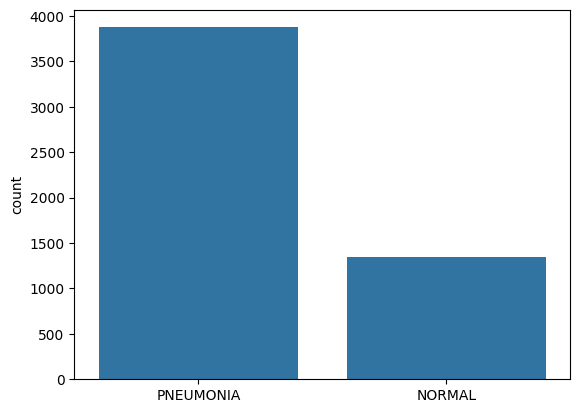

In [25]:
l = []

for i in train:

    if i[1] == 0:
        l.append("PNEUMONIA")
    else:
        l.append("NORMAL")

sns.countplot(x=l)

plt.show()

Text(0.5, 1.0, 'NORMAL')

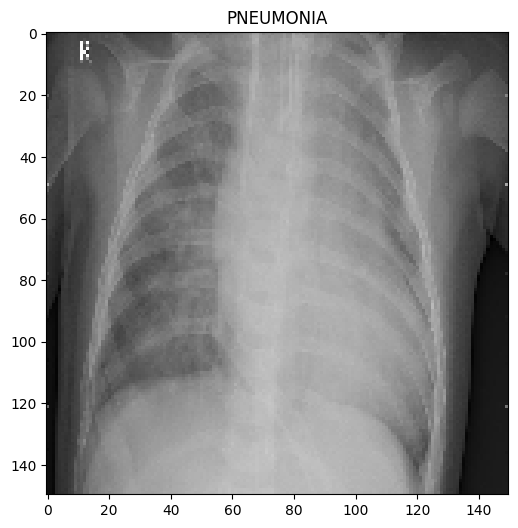

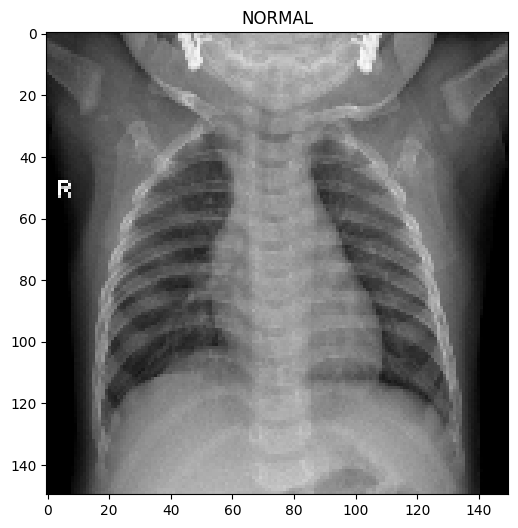

In [26]:
plt.figure(figsize=(6,6))

plt.imshow(train[0][0], cmap='gray')
plt.title(labels[train[0][1]])

plt.figure(figsize=(6,6))

plt.imshow(train[-11][0], cmap='gray')
plt.title(labels[train[-11][1]])

In [27]:
x_train = []
y_train = []

x_val = []
y_val = []

x_test = []
y_test = []

for feat, label in train:

    x_train.append(feat)
    y_train.append(label)

for feat, label in val:

    x_val.append(feat)
    y_val.append(label)

for feat, label in test:

    x_test.append(feat)
    y_test.append(label)

In [28]:
x_train = np.array(x_train) / 255.0
x_val = np.array(x_val) / 255.0
x_test = np.array(x_test) / 255.0

y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)


In [29]:
x_train

array([[[0.16078431, 0.16470588, 0.17647059, ..., 0.18431373,
         0.17647059, 0.16078431],
        [0.16078431, 0.16862745, 0.2       , ..., 0.19607843,
         0.18823529, 0.18039216],
        [0.14901961, 0.16862745, 0.20784314, ..., 0.21176471,
         0.2       , 0.18431373],
        ...,
        [0.05882353, 0.05490196, 0.03137255, ..., 0.10588235,
         0.10980392, 0.10980392],
        [0.05490196, 0.05098039, 0.02745098, ..., 0.10980392,
         0.10980392, 0.10980392],
        [0.05490196, 0.05098039, 0.02745098, ..., 0.10980392,
         0.10980392, 0.10980392]],

       [[0.15686275, 0.10980392, 0.12156863, ..., 0.17647059,
         0.17647059, 0.17254902],
        [0.40392157, 0.11764706, 0.12156863, ..., 0.17254902,
         0.17254902, 0.17254902],
        [0.62352941, 0.12941176, 0.12941176, ..., 0.16470588,
         0.16862745, 0.17254902],
        ...,
        [0.09411765, 0.07843137, 0.10196078, ..., 0.12156863,
         0.12156863, 0.12156863],
        [0.1

In [30]:
x_train = x_train.reshape(-1,150,150,1)

x_val = x_val.reshape(-1,150,150,1)

x_test = x_test.reshape(-1,150,150,1)

In [31]:
datagen = ImageDataGenerator(

    rotation_range = 15,

    zoom_range = 0.1,

    width_shift_range = 0.1,

    height_shift_range = 0.1,

    horizontal_flip = True

)

datagen.fit(x_train)


###Training the model

In [32]:

model = Sequential()

# BLOCK 1
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(150,150,1)
    )
)

model.add(BatchNormalization())

model.add(MaxPool2D((2,2)))

# BLOCK 2
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    )
)

model.add(BatchNormalization())

model.add(MaxPool2D((2,2)))

model.add(Dropout(0.5))

# BLOCK 3
model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    )
)

model.add(BatchNormalization())

model.add(MaxPool2D((2,2)))

model.add(Dropout(0.5))

# FLATTEN
model.add(Flatten())

# DENSE
model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

# OUTPUT
model.add(Dense(1, activation='sigmoid'))

model.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']

)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
learning_rate_reduction = ReduceLROnPlateau(

    monitor='val_accuracy',

    patience=2,

    verbose=1,

    factor=0.3,

    min_lr=0.000001
)

early_stop = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True
)

In [34]:
history = model.fit(

    datagen.flow(x_train, y_train, batch_size=32),

    epochs=30,

    validation_data=(x_val, y_val),

    callbacks=[
        learning_rate_reduction,
        early_stop
    ]
)

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 493s 3s/step - accuracy: 0.8075 - loss: 1.0421 - val_accuracy: 0.5000 - val_loss: 40.8162 - learning_rate: 0.0010
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 542s 3s/step - accuracy: 0.8721 - loss: 0.3299 - val_accuracy: 0.6250 - val_loss: 4.1780 - learning_rate: 0.0010
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 511s 3s/step - accuracy: 0.8928 - loss: 0.2899 - val_accuracy: 0.5625 - val_loss: 2.8437 - learning_rate: 0.0010
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8944 - loss: 0.2975
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
163/163 ━━━━━━━━━━━━━━━━━━━━ 502s 3s/step - accuracy: 0.8951 - loss: 0.2897 - val_accuracy: 0.5000 - val_loss: 10.5563 - learning_rate: 0.0010
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 505s 3s/step - accuracy: 0.9183 - loss: 0.2633 - val_accuracy: 0.6875 - val_loss: 0.6244 - learning_rate: 3.0000e-04
Epoch 6/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 498s 3s/step - accuracy: 0.9143 - loss:

In [35]:
loss, accuracy = model.evaluate(x_test, y_test)

print(f"Test Loss : {loss}")

print(f"Test Accuracy : {accuracy*100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 829ms/step - accuracy: 0.8766 - loss: 0.3312
Test Loss : 0.33119553327560425
Test Accuracy : 87.66%


###Analyse Model Performance

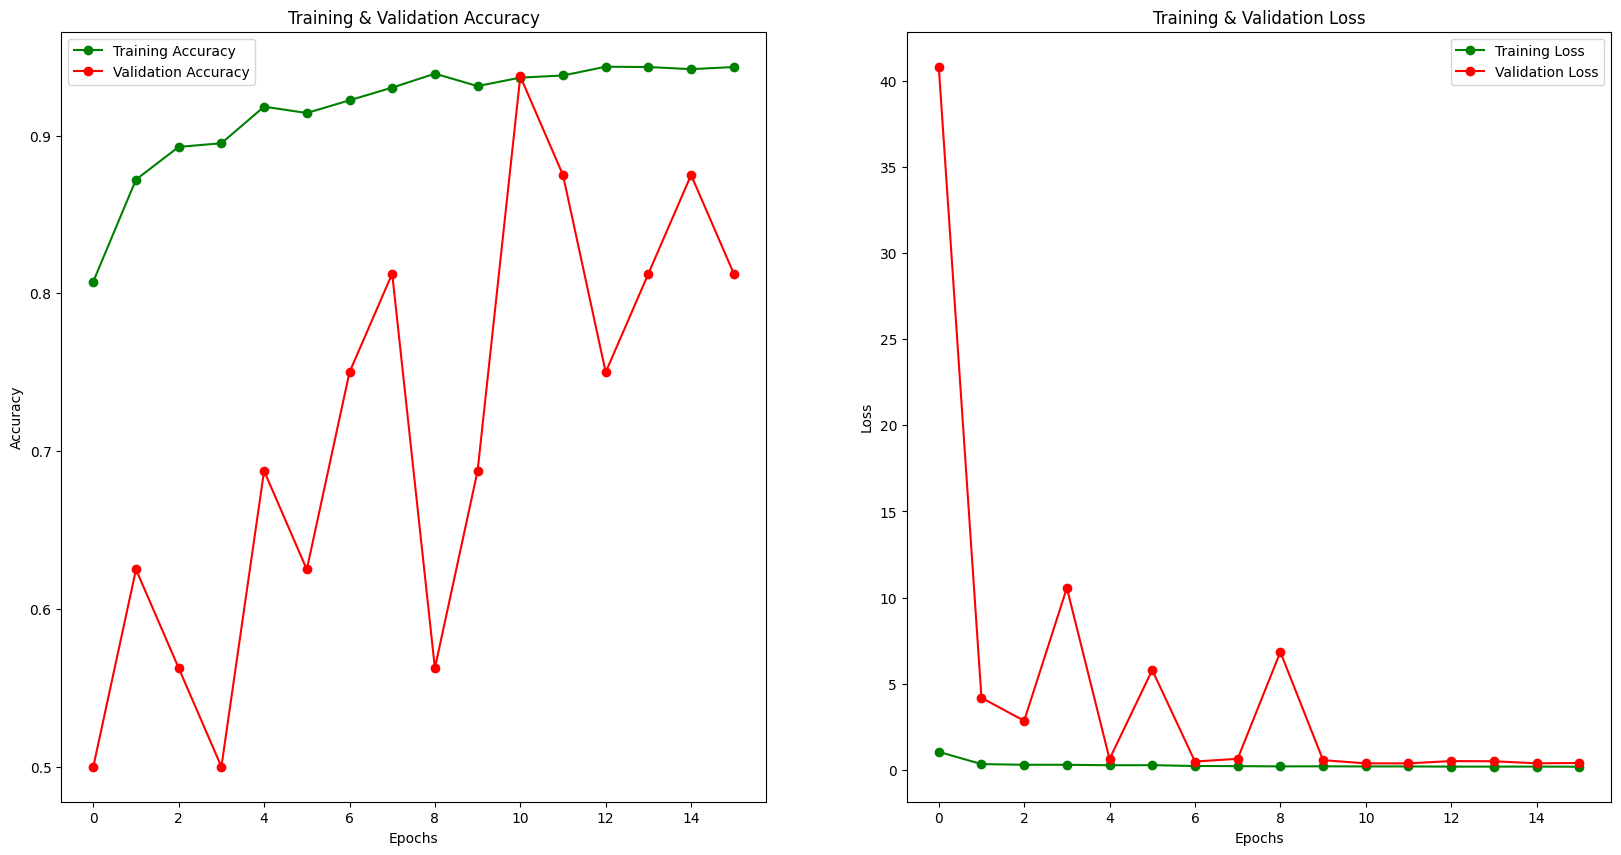

In [36]:
epochs = range(len(history.history['accuracy']))

fig, ax = plt.subplots(1,2)

train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

fig.set_size_inches(20,10)

ax[0].plot(epochs, train_acc, 'go-', label='Training Accuracy')
ax[0].plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
ax[0].set_title('Training & Validation Accuracy')
ax[0].legend()
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')

ax[1].plot(epochs, train_loss, 'g-o', label='Training Loss')
ax[1].plot(epochs, val_loss, 'r-o', label='Validation Loss')
ax[1].set_title('Training & Validation Loss')
ax[1].legend()
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')

plt.show()

In [37]:
predictions = (model.predict(x_test) > 0.5).astype('int32')
predictions = predictions.reshape(1,-1)[0]
predictions[:15]

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 572ms/step


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [38]:
print(classification_report(y_test, predictions, target_names=['Pneumonia (Class 0)', 'Normal (Class 1)']))

                     precision    recall  f1-score   support

Pneumonia (Class 0)       0.89      0.91      0.90       390
   Normal (Class 1)       0.85      0.82      0.83       234

           accuracy                           0.88       624
          macro avg       0.87      0.87      0.87       624
       weighted avg       0.88      0.88      0.88       624



In [39]:

cm = confusion_matrix(y_test,predictions)


In [40]:

cm

array([[355,  35],
       [ 42, 192]])

In [41]:
correct = np.nonzero(predictions == y_test)[0]
incorrect = np.nonzero(predictions != y_test)[0]

###Some Correctly Predicted Classes

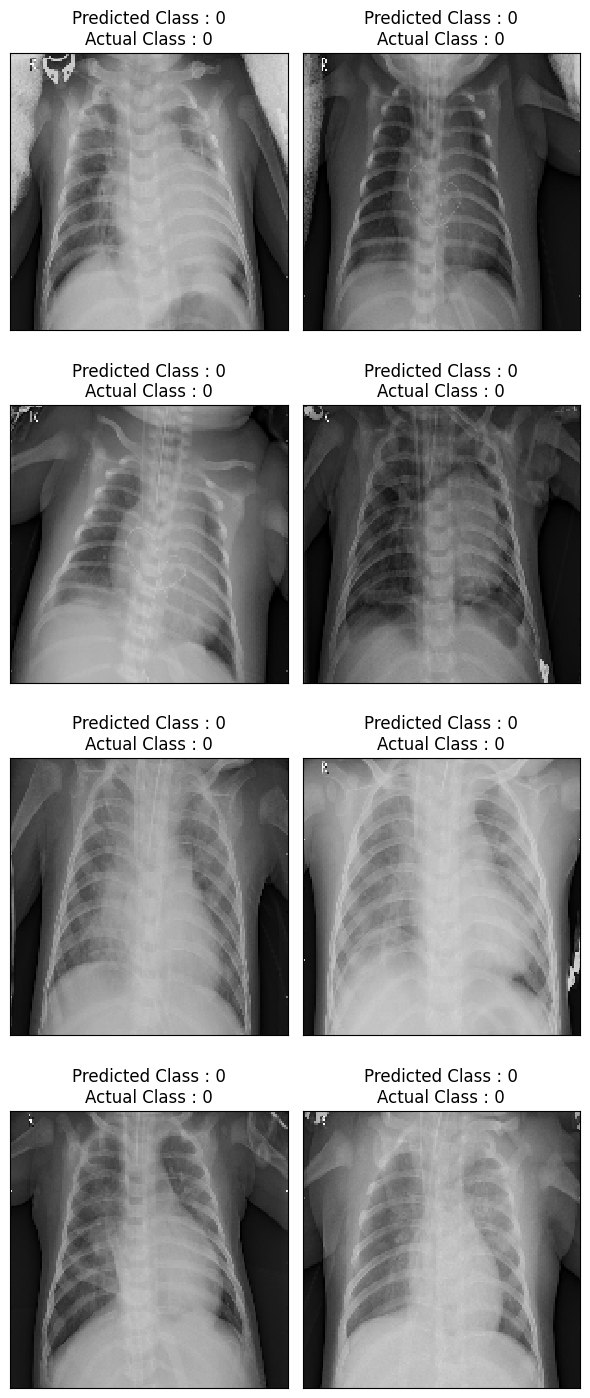

In [42]:
i = 0
plt.figure(figsize=(6,15))
for c in correct[10:18]:
  plt.subplot(4,2,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_test[c].reshape(150,150), cmap='gray', interpolation='none')
  plt.title(f"Predicted Class : {predictions[c]}\nActual Class : {y_test[c]}")
  plt.tight_layout()
  i += 1

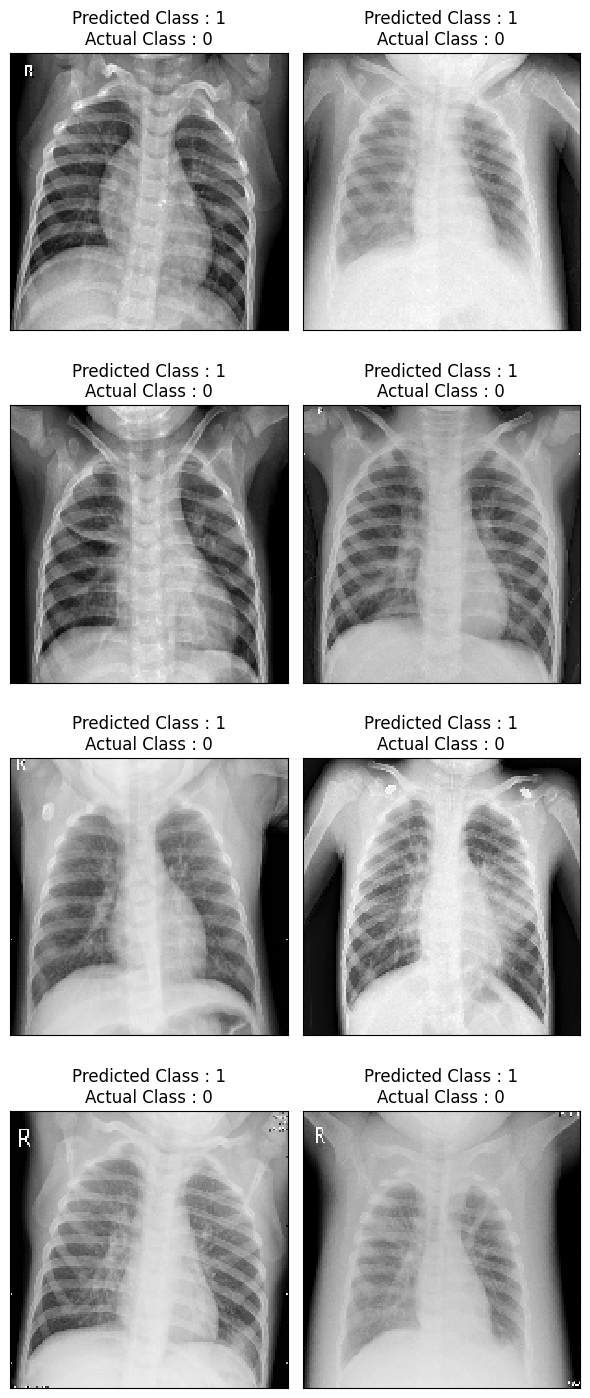

In [43]:
i = 0
plt.figure(figsize=(6,15))
for c in incorrect[10:18]:
  plt.subplot(4,2,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_test[c].reshape(150,150), cmap='gray', interpolation='none')
  plt.title(f"Predicted Class : {predictions[c]}\nActual Class : {y_test[c]}")
  plt.tight_layout()
  i += 1

###Predicative System

In [46]:
def predict_image(image_path):

    # READ IMAGE
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # RESIZE IMAGE
    img_resized = cv2.resize(img, (150,150))

    # NORMALIZE
    img_normalized = img_resized / 255.0

    # RESHAPE FOR CNN
    img_reshaped = img_normalized.reshape(1,150,150,1)

    # PREDICT
    prediction = model.predict(img_reshaped)

    # PROBABILITY
    probability = prediction[0][0]

    # DISPLAY IMAGE
    plt.figure(figsize=(6,6))

    plt.imshow(img_resized, cmap='gray')

    # RESULT
    if probability > 0.5:

        result = "NORMAL"

    else:

        result = "PNEUMONIA"

    plt.title(f"Prediction : {result}")

    plt.axis('off')

    plt.show()

    # PRINT CONFIDENCE
    print("Prediction Probability :", probability)

    print("Final Prediction :", result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


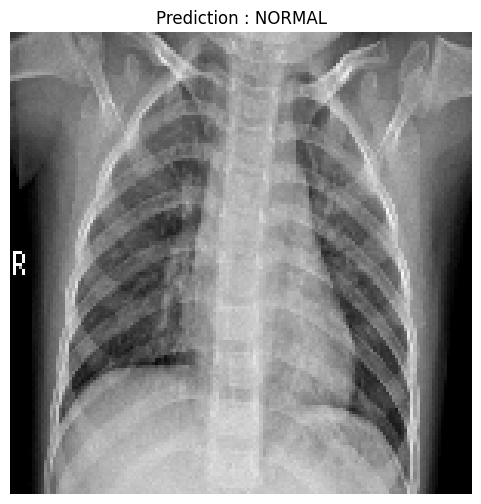

Prediction Probability : 0.817226
Final Prediction : NORMAL


In [47]:
predict_image('/content/drive/MyDrive/Pneumonia_Project/chest_xray/test/NORMAL/NORMAL2-IM-0347-0001.jpeg')